# 1D-CNN + Transformer Model Training for WESAD Dataset

This notebook trains a hybrid 1D-CNN + Transformer model to classify stress, amusement, and baseline states using the WESAD dataset.

In [1]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
import glob
import math
import pandas as pd

## 1. Configuration and Setup

In [2]:
# Configuration
DATASET_PATH = '/home/binghin2/Myproject/Dataset/WESAD'
TRAIN_USERS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11']
VAL_USERS = ['S13', 'S14'] 
TEST_USERS = ['S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2} # 1: baseline, 2: stress, 3: amusement -> 0, 1, 2
N_FEATURES = 10 # ACC (3), BVP (1), SCL (1), SCR (1), TEMP (1), HR (1), IBI (1), HRV (1)
DOWNSAMPLE_RATE = 4 # Hz, the rate to downsample all signals to
WINDOW_SIZE_SEC = 60 # seconds # 0~60, 1~61 , 2~62 
TRAIN_STRIDE_SEC = 10 # default seconds for training (used when dynamic stride is disabled)
TEST_STRIDE_SEC = 60 # seconds (no overlap for evaluation)
LABEL_PURITY_THRESHOLD = 0.8 # Keep only windows where dominant label ratio >= 80%

# Dynamic stride for training windows (raw labels: 1=baseline, 2=stress, 3=amusement)
TRAIN_DYNAMIC_STRIDE_MAP = {
    1: 15,  # baseline -> sparse sampling
    2: 10,  # stress -> normal sampling
    3: 5    # amusement -> dense sampling (oversampling)
}

# 1D-CNN + Transformer Hyperparameters
# CNN_OUT_CHANNELS = 64 # Output channels for CNN
CNN_OUT_CHANNELS = 32 # Output channels for CNN
CNN_KERNEL_SIZE = 3 # Kernel size for CNN
CNN_POOL_SIZE = 2 # Max pooling size
D_MODEL = 32 # Embedding dimension for Transformer
#D_MODEL = 64 # Embedding dimension for Transformer
NHEAD = 4 # Number of attention heads
#DIM_FEEDFORWARD = 256 # Dimension of feedforward network
DIM_FEEDFORWARD = 128 # Dimension of feedforward network
NLAYERS = 2 # Number of transformer layers
OUTPUT_DIM = len(TARGET_LABELS)
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 0.0005
DROPOUT = 0.5

# Setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


## 2. Data Loading and Preprocessing

In [3]:
def _to_2d_column(signal):
    """Ensures signal is 2D: (time, channels)."""
    signal = np.asarray(signal)
    if signal.ndim == 1:
        return signal.reshape(-1, 1)
    return signal

def _resample_signal(signal, orig_rate, target_rate):
    """Anti-aliasing resampling using polyphase filtering."""
    signal_2d = _to_2d_column(signal)
    if orig_rate == target_rate:
        return signal_2d
    return resample_poly(signal_2d, up=target_rate, down=orig_rate, axis=0)

def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    """Decompose EDA into SCL (tonic) and SCR (phasic)."""
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    normalized_cutoff = cutoff_hz / nyq
    b, a = butter(order, normalized_cutoff, btype='low')

    if len(eda_flat) <= (max(len(a), len(b)) * 3):
        scl = np.copy(eda_flat)
    else:
        scl = filtfilt(b, a, eda_flat)

    scr = eda_flat - scl
    return scl.reshape(-1, 1), scr.reshape(-1, 1)

def extract_bvp_features(bvp, orig_rate=64, target_rate=4):
    """
    Extract HR, IBI, and HRV from raw BVP and interpolate them to target_rate.
    Returns shape: (N, 3) -> [HR, IBI, HRV]
    """
    bvp_flat = np.asarray(bvp).flatten()

    min_distance = int(orig_rate * 0.3)
    peaks, _ = find_peaks(bvp_flat, distance=min_distance)

    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)

    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]

        hr_continuous = np.interp(times_target, peak_times, hr)
        ibi_continuous = np.interp(times_target, peak_times, ibi)

        ibi_series = pd.Series(ibi_continuous)
        hrv_continuous = (
            ibi_series
            .rolling(window=target_rate * 10, min_periods=1)
            .std()
            .fillna(0.0)
            .values
        )
    else:
        hr_continuous = np.zeros(target_len)
        ibi_continuous = np.zeros(target_len)
        hrv_continuous = np.zeros(target_len)

    hr_continuous = hr_continuous.reshape(-1, 1)
    ibi_continuous = ibi_continuous.reshape(-1, 1)
    hrv_continuous = hrv_continuous.reshape(-1, 1)

    return np.concatenate([hr_continuous, ibi_continuous, hrv_continuous], axis=1)

def load_and_preprocess_data(subject_path):
    """Loads data, extracts BVP/EDA features, resamples, synchronizes, and normalizes."""
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # --- Extract Wrist Data --- #
    wrist_data = data['signal']['wrist']
    acc = wrist_data['ACC']      # 32 Hz, shape: (T, 3)
    bvp = wrist_data['BVP']      # 64 Hz, shape: (T,) or (T, 1)
    eda = wrist_data['EDA']      # 4 Hz,  shape: (T,) or (T, 1)
    temp = wrist_data['TEMP']    # 4 Hz,  shape: (T,) or (T, 1)
    labels = data['label']       # 700 Hz

    # Extract HR/IBI/HRV from raw 64 Hz BVP before downsampling
    bvp_features = extract_bvp_features(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)

    # Decompose EDA(4Hz) -> SCL/SCR before downsampling
    scl_eda, scr_eda = decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2)

    # --- Resample raw signals to DOWNSAMPLE_RATE --- #
    acc_down = _resample_signal(acc, orig_rate=32, target_rate=DOWNSAMPLE_RATE)
    bvp_down = _resample_signal(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    scl_down = _resample_signal(scl_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    scr_down = _resample_signal(scr_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    temp_down = _resample_signal(temp, orig_rate=4, target_rate=DOWNSAMPLE_RATE)

    # Align labels by nearest timestamp (categorical label -> no interpolation)
    label_timestamps = np.arange(len(labels)) / 700.0
    data_timestamps = np.arange(len(acc_down)) / float(DOWNSAMPLE_RATE)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)

    # Find minimum common length and truncate
    min_len = min(
        len(acc_down), len(bvp_down), len(scl_down), len(scr_down), len(temp_down), len(bvp_features), len(labels_down)
    )

    # --- Combine Features --- #
    features = np.concatenate([
        acc_down[:min_len],
        bvp_down[:min_len],
        scl_down[:min_len],
        scr_down[:min_len],
        temp_down[:min_len],
        bvp_features[:min_len]
    ], axis=1)

    # --- Subject-wise normalization --- #
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    labels_final = labels_down[:min_len]

    return features_scaled, labels_final

def create_windows(features, labels, stride_sec, dynamic_stride_map=None, apply_dynamic_stride=False):
    """Creates sliding windows and keeps only label-pure windows.

    - Fixed mode: uses stride_sec for all windows.
    - Dynamic mode: stride is selected by dominant raw label in each window.
    """
    window_samples = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    default_stride_samples = max(1, int(stride_sec * DOWNSAMPLE_RATE))

    X, y = [], []
    i = 0
    max_start = len(features) - window_samples

    while i <= max_start:
        window_features = features[i : i + window_samples]
        window_labels = labels[i : i + window_samples].astype(int)

        counts = np.bincount(window_labels)
        if counts.size == 0:
            i += default_stride_samples
            continue

        most_frequent_label = int(counts.argmax())
        label_purity = counts[most_frequent_label] / float(window_samples)

        if most_frequent_label in TARGET_LABELS and label_purity >= LABEL_PURITY_THRESHOLD:
            X.append(window_features)
            y.append(TARGET_LABELS[most_frequent_label])

        if apply_dynamic_stride and dynamic_stride_map is not None:
            stride_next_sec = dynamic_stride_map.get(most_frequent_label, stride_sec)
            stride_next_samples = max(1, int(stride_next_sec * DOWNSAMPLE_RATE))
        else:
            stride_next_samples = default_stride_samples

        i += stride_next_samples

    return np.array(X), np.array(y)

In [4]:
# --- Process TRAIN users (overlap allowed). Skip users reserved for VAL/TEST --- #
train_X, train_y = [], []
for user in TRAIN_USERS:
    if user in VAL_USERS or user in TEST_USERS:
        print(f'Skipping user {user} (reserved for VAL/TEST)')
        continue
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing TRAIN user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(
            features,
            labels,
            stride_sec=TRAIN_STRIDE_SEC,
            dynamic_stride_map=TRAIN_DYNAMIC_STRIDE_MAP,
            apply_dynamic_stride=True
        )
        if X_user.size > 0:
            train_X.append(X_user)
            train_y.append(y_user)

if len(train_X) == 0:
    raise ValueError('No training data found. Check TRAIN_USERS or DATASET_PATH.')

X_train = np.concatenate(train_X, axis=0)
y_train = np.concatenate(train_y, axis=0)

print(f'\nTotal TRAIN windows created: {len(X_train)}')
print(f'TRAIN feature shape: {X_train.shape}')
print(f'TRAIN label distribution: {np.bincount(y_train)}')

# --- Process VAL users (no overlap by default using TEST_STRIDE_SEC) --- #
val_X, val_y = [], []
for user in VAL_USERS:
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing VAL user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(features, labels, stride_sec=TEST_STRIDE_SEC)
        if X_user.size > 0:
            val_X.append(X_user)
            val_y.append(y_user)

if len(val_X) == 0:
    raise ValueError('No validation data found. Check VAL_USERS or DATASET_PATH.')

X_val = np.concatenate(val_X, axis=0)
y_val = np.concatenate(val_y, axis=0)

print(f'\nTotal VAL windows created: {len(X_val)}')
print(f'VAL feature shape: {X_val.shape}')
print(f'VAL label distribution: {np.bincount(y_val)}')

# --- Process TEST users (non-overlapping windows) --- #
test_X, test_y = [], []
for user in TEST_USERS:
    subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
    if os.path.exists(subject_path):
        print(f'Processing TEST user: {user}...')
        features, labels = load_and_preprocess_data(subject_path)
        X_user, y_user = create_windows(features, labels, stride_sec=TEST_STRIDE_SEC)
        if X_user.size > 0:
            test_X.append(X_user)
            test_y.append(y_user)

if len(test_X) == 0:
    raise ValueError('No test data found. Check TEST_USERS or DATASET_PATH.')

X_test = np.concatenate(test_X, axis=0)
y_test = np.concatenate(test_y, axis=0)

print(f'\nTest set size: {len(X_test)}')
print(f'TEST feature shape: {X_test.shape}')
print(f'TEST label distribution: {np.bincount(y_test)}')

# Subject-wise normalization is already applied in load_and_preprocess_data()

Processing TRAIN user: S2...
Processing TRAIN user: S3...
Processing TRAIN user: S4...
Processing TRAIN user: S5...
Processing TRAIN user: S6...
Processing TRAIN user: S7...
Processing TRAIN user: S8...
Processing TRAIN user: S9...
Processing TRAIN user: S10...
Processing TRAIN user: S11...

Total TRAIN windows created: 2044
TRAIN feature shape: (2044, 240, 10)
TRAIN label distribution: [759 617 668]
Processing VAL user: S13...
Processing VAL user: S14...

Total VAL windows created: 71
VAL feature shape: (71, 240, 10)
VAL label distribution: [38 21 12]
Processing TEST user: S15...
Processing TEST user: S16...
Processing TEST user: S17...

Test set size: 108
TEST feature shape: (108, 240, 10)
TEST label distribution: [57 33 18]


## 3. PyTorch Dataset and DataLoader

In [5]:
class WesadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WesadDataset(X_train, y_train)
val_dataset = WesadDataset(X_val, y_val)
test_dataset = WesadDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. 1D-CNN + Transformer Model Definition

In [6]:
class PositionalEncoding(nn.Module):
    """Positional encoding for Transformer model (from PyTorch docs)"""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

class CNNTransformerModel(nn.Module):
    """Hybrid 1D-CNN + Transformer model for time series classification"""
    def __init__(self, input_dim, cnn_out_channels, cnn_kernel_size, cnn_pool_size,
                 d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.1):
        super(CNNTransformerModel, self).__init__()
        
        # 1D-CNN layers for feature extraction
        self.conv1 = nn.Conv1d(input_dim, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(cnn_pool_size)
        
        self.conv2 = nn.Conv1d(cnn_out_channels, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(cnn_pool_size)
        
        # Projection layer to map CNN output to Transformer input dimension
        self.cnn_to_transformer = nn.Linear(cnn_out_channels, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        # Stack multiple transformer encoder layers
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        
        # Output layer
        self.fc = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        
        # Transpose for CNN: (batch_size, input_dim, seq_len)
        x = x.transpose(1, 2)
        
        # First CNN block
        x = self.conv1(x)  # (batch_size, cnn_out_channels, seq_len)
        x = self.relu1(x)
        x = self.pool1(x)  # (batch_size, cnn_out_channels, seq_len//pool_size)
        
        # Second CNN block
        x = self.conv2(x)  # (batch_size, cnn_out_channels, seq_len//pool_size)
        x = self.relu2(x)
        x = self.pool2(x)  # (batch_size, cnn_out_channels, seq_len//pool_size//pool_size)
        
        # Transpose back for Transformer: (batch_size, seq_len, cnn_out_channels)
        x = x.transpose(1, 2)
        
        # Project CNN output to Transformer input dimension
        x = self.cnn_to_transformer(x)  # (batch_size, seq_len, d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)  # (batch_size, seq_len, d_model)
        
        # Transformer encoder
        x = self.transformer_encoder(x)  # (batch_size, seq_len, d_model)
        
        # Use the last token's output for classification
        x = x[:, -1, :]  # (batch_size, d_model)
        
        # Output layer
        x = self.fc(x)  # (batch_size, output_dim)
        
        return x

## 5. Model Training

In [7]:
from sklearn.metrics import f1_score

class FocalLoss(nn.Module):
    """Multi-class Focal Loss with optional per-class alpha weights."""
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

model = CNNTransformerModel(
    input_dim=N_FEATURES,
    cnn_out_channels=CNN_OUT_CHANNELS,
    cnn_kernel_size=CNN_KERNEL_SIZE,
    cnn_pool_size=CNN_POOL_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    dim_feedforward=DIM_FEEDFORWARD,
    nlayers=NLAYERS,
    output_dim=OUTPUT_DIM,
    dropout=DROPOUT
)
model.to(device)

# Class weights (inverse frequency) + Focal Loss
class_counts = np.bincount(y_train, minlength=OUTPUT_DIM).astype(np.float32)
class_counts = np.clip(class_counts, a_min=1.0, a_max=None)
class_weights_np = 1.0 / class_counts
class_weights_np = class_weights_np / class_weights_np.sum()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
print(f"Class counts (train): {class_counts.astype(int)}")
print(f"Class weights       : {class_weights_np}")

FOCAL_GAMMA = 2.0
criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA, reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Early Stopping 설정 (Validation Macro F1 기준)
PATIENCE = 10
MIN_DELTA = 1e-4
best_val_macro_f1 = -float("inf")
epochs_no_improve = 0
best_model_state = None

print("Starting training with Focal Loss + Macro-F1 Early Stopping...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for i, (sequences, labels) in enumerate(train_loader):
        sequences = sequences.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * sequences.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples) * 100

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for sequences, labels in val_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)

            outputs = model(sequences)
            val_loss = criterion(outputs, labels)

            val_running_loss += val_loss.item() * sequences.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_epoch_loss = val_running_loss / val_total
    val_epoch_acc = (val_correct / val_total) * 100
    val_epoch_macro_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
        f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%, Val Macro F1: {val_epoch_macro_f1:.4f}"
    )

    # Early Stopping 체크 (Validation Macro F1 기준)
    if val_epoch_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_epoch_macro_f1
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        print(f"  ✅ Validation Macro F1 improved. Best Val Macro F1: {best_val_macro_f1:.4f}")
    else:
        epochs_no_improve += 1
        print(f"  ⏳ No Macro F1 improvement for {epochs_no_improve}/{PATIENCE} epoch(s)")

        if epochs_no_improve >= PATIENCE:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            break

# best weight 복원
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    print(f"✅ Loaded best model weights (Best Val Macro F1: {best_val_macro_f1:.4f})")

Class counts (train): [759 617 668]
Class weights       : [0.29705557 0.36542168 0.33752275]
Starting training with Focal Loss + Macro-F1 Early Stopping...
Epoch [1/50] | Train Loss: 0.0313, Train Acc: 46.23% | Val Loss: 0.0224, Val Acc: 50.70%, Val Macro F1: 0.5316
  ✅ Validation Macro F1 improved. Best Val Macro F1: 0.5316
Epoch [2/50] | Train Loss: 0.0117, Train Acc: 74.32% | Val Loss: 0.0347, Val Acc: 50.70%, Val Macro F1: 0.4750
  ⏳ No Macro F1 improvement for 1/10 epoch(s)
Epoch [3/50] | Train Loss: 0.0078, Train Acc: 78.18% | Val Loss: 0.0427, Val Acc: 43.66%, Val Macro F1: 0.4288
  ⏳ No Macro F1 improvement for 2/10 epoch(s)
Epoch [4/50] | Train Loss: 0.0061, Train Acc: 83.37% | Val Loss: 0.0375, Val Acc: 49.30%, Val Macro F1: 0.4798
  ⏳ No Macro F1 improvement for 3/10 epoch(s)
Epoch [5/50] | Train Loss: 0.0048, Train Acc: 87.87% | Val Loss: 0.0390, Val Acc: 54.93%, Val Macro F1: 0.5626
  ✅ Validation Macro F1 improved. Best Val Macro F1: 0.5626
Epoch [6/50] | Train Loss: 0.00

In [8]:
# 학습 완료 후 모델 저장
SAVE_DIR = "Save_model"
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(SAVE_DIR, "CT_0313_focal_model.pt")

checkpoint = {
    "model_name": "CNN_Transformer",
    "model_state_dict": model.state_dict(),
    "n_features": N_FEATURES,
    "cnn_out_channels": CNN_OUT_CHANNELS,
    "cnn_kernel_size": CNN_KERNEL_SIZE,
    "cnn_pool_size": CNN_POOL_SIZE,
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "dim_feedforward": DIM_FEEDFORWARD,
    "nlayers": NLAYERS,
    "output_dim": OUTPUT_DIM,
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"✅ Model saved to: {MODEL_SAVE_PATH}")

✅ Model saved to: Save_model/CT_0313_focal_model.pt


## 6. Model Evaluation

In [9]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        outputs = model(sequences)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'\nTest Accuracy: {accuracy:.2f} %')

# Optional: Print classification report for more details
try:
    from sklearn.metrics import classification_report
    report = classification_report(all_labels, all_preds, target_names=['baseline', 'stress', 'amusement'])
    print("\nClassification Report:")
    print(report)
except ImportError:
    print("\nPlease install scikit-learn to see the classification report: pip install -U scikit-learn")

# 각 클래스별 정확도 계산
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)

class_names = ['Baseline', 'Stress', 'Amusement']
print("\n" + "="*60)
print("각 상태별 정확도")
print("="*60)

for class_idx, class_name in enumerate(class_names):
    # 해당 클래스의 샘플들
    class_mask = all_labels_np == class_idx
    class_total = class_mask.sum()
    
    if class_total > 0:
        # 해당 클래스에서 올바르게 예측된 샘플들
        class_correct = ((all_labels_np == class_idx) & (all_preds_np == class_idx)).sum()
        class_accuracy = (class_correct / class_total) * 100
        print(f"{class_name}: {class_accuracy:.2f}% ({class_corret}/{class_total})")
    else:
        print(f"{class_name}: N/A (no samples)")

print("="*60)


Test Accuracy: 76.85 %

Classification Report:
              precision    recall  f1-score   support

    baseline       0.90      0.81      0.85        57
      stress       0.89      0.73      0.80        33
   amusement       0.43      0.72      0.54        18

    accuracy                           0.77       108
   macro avg       0.74      0.75      0.73       108
weighted avg       0.82      0.77      0.78       108


각 상태별 정확도
Baseline: 80.70% (46/57)
Stress: 72.73% (24/33)
Amusement: 72.22% (13/18)


Overall Accuracy / Error Rate
Accuracy   : 76.85%
Error Rate : 23.15%

Class-wise Accuracy / Error Rate


,Class,Total,Correct,Accuracy(%),Error Rate(%)
0,Baseline,57,46,80.701754,19.298246
1,Stress,33,24,72.727273,27.272727
2,Amusement,18,13,72.222222,27.777778


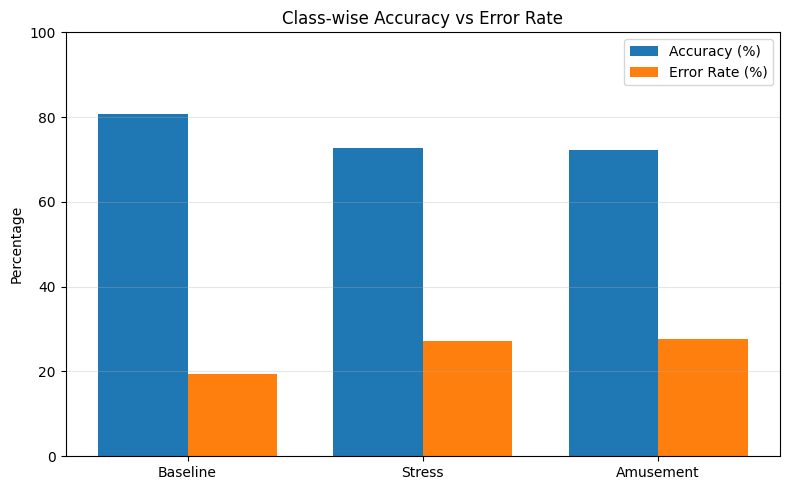

In [12]:
# Error Rate 기반 Accuracy 분석
import pandas as pd
import matplotlib.pyplot as plt

if "all_labels" not in globals() or "all_preds" not in globals():
    raise NameError("`all_labels` 또는 `all_preds`가 없습니다. 먼저 16번 셀(모델 평가)을 실행하세요.")

all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)
class_names = ['Baseline', 'Stress', 'Amusement']

# 전체 지표
overall_accuracy = (all_labels_np == all_preds_np).mean() * 100
overall_error_rate = 100 - overall_accuracy
print("=" * 70)
print("Overall Accuracy / Error Rate")
print("=" * 70)
print(f"Accuracy   : {overall_accuracy:.2f}%")
print(f"Error Rate : {overall_error_rate:.2f}%")
print("=" * 70)

# 클래스별 지표
rows = []
for class_idx, class_name in enumerate(class_names):
    mask = all_labels_np == class_idx
    total = int(mask.sum())
    correct = int(((all_labels_np == class_idx) & (all_preds_np == class_idx)).sum())
    acc = (correct / total) * 100 if total > 0 else np.nan
    err = 100 - acc if total > 0 else np.nan
    rows.append({
        "Class": class_name,
        "Total": total,
        "Correct": correct,
        "Accuracy(%)": acc,
        "Error Rate(%)": err,
    })

df_error_analysis = pd.DataFrame(rows)
print("\nClass-wise Accuracy / Error Rate")
display(df_error_analysis)

# 시각화: 클래스별 Accuracy vs Error Rate
x = np.arange(len(class_names))
acc_vals = df_error_analysis["Accuracy(%)"].values
err_vals = df_error_analysis["Error Rate(%)"].values

plt.figure(figsize=(8, 5))
bar_w = 0.38
plt.bar(x - bar_w / 2, acc_vals, width=bar_w, label="Accuracy (%)")
plt.bar(x + bar_w / 2, err_vals, width=bar_w, label="Error Rate (%)")
plt.xticks(x, class_names)
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title("Class-wise Accuracy vs Error Rate")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Inference Time Benchmark (CNN+Transformer)
import time
import numpy as np
import torch

if "model" not in globals():
    raise NameError("`model` 변수가 없습니다. 모델 생성/학습 셀을 먼저 실행하세요.")
if "test_loader" not in globals():
    raise NameError("`test_loader` 변수가 없습니다. DataLoader 생성 셀을 먼저 실행하세요.")

runtime_device = device if "device" in globals() else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(runtime_device)
model.eval()


def _sync_if_cuda(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def benchmark_inference(model, data_loader, dev, warmup_steps=20):
    iterator = iter(data_loader)
    first_batch = next(iterator)
    x0 = first_batch[0].to(dev)

    for _ in range(warmup_steps):
        _ = model(x0)
    _sync_if_cuda(dev)

    batch_times = []
    total_samples = 0

    for inputs, _ in data_loader:
        inputs = inputs.to(dev)

        _sync_if_cuda(dev)
        t0 = time.perf_counter()
        _ = model(inputs)
        _sync_if_cuda(dev)
        t1 = time.perf_counter()

        batch_times.append((t1 - t0) * 1000.0)
        total_samples += inputs.size(0)

    total_time_ms = float(np.sum(batch_times))
    avg_batch_ms = float(np.mean(batch_times))
    std_batch_ms = float(np.std(batch_times))
    avg_sample_ms = total_time_ms / max(total_samples, 1)
    throughput = total_samples / (total_time_ms / 1000.0)

    return {
        "num_batches": len(batch_times),
        "num_samples": total_samples,
        "total_time_ms": total_time_ms,
        "avg_batch_ms": avg_batch_ms,
        "std_batch_ms": std_batch_ms,
        "avg_sample_ms": avg_sample_ms,
        "throughput_sps": throughput,
    }


stats = benchmark_inference(model, test_loader, runtime_device, warmup_steps=20)

print("=" * 70)
print("CNN+Transformer Inference Benchmark (Test Loader)")
print("=" * 70)
print(f"Device            : {runtime_device}")
print(f"Batches           : {stats['num_batches']}")
print(f"Samples           : {stats['num_samples']}")
print(f"Total time        : {stats['total_time_ms']:.2f} ms")
print(f"Avg batch latency : {stats['avg_batch_ms']:.3f} ± {stats['std_batch_ms']:.3f} ms")
print(f"Avg sample latency: {stats['avg_sample_ms']:.4f} ms/sample")
print(f"Throughput        : {stats['throughput_sps']:.2f} samples/sec")

CNN+Transformer Inference Benchmark (Test Loader)
Device            : cuda:0
Batches           : 2
Samples           : 108
Total time        : 1.25 ms
Avg batch latency : 0.624 ± 0.019 ms
Avg sample latency: 0.0116 ms/sample
Throughput        : 86494.59 samples/sec


In [11]:
# 실시간 환경(Batch Size 1)을 위한 전용 로더 생성
realtime_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# 기존의 벤치마크 함수를 그대로 사용하여 측정
stats_rt = benchmark_inference(model, realtime_loader, runtime_device, warmup_steps=50)

print("=" * 70)
print("실시간 응답 시간 측정 결과 (Batch Size = 1)")
print("=" * 70)
print(f"Device            : {runtime_device}")
print(f"순수 모델 응답 시간 : {stats_rt['avg_batch_ms']:.3f} ms") 
print(f"초당 처리 가능 횟수 : {stats_rt['throughput_sps']:.2f} FPS")
print("=" * 70)

실시간 응답 시간 측정 결과 (Batch Size = 1)
Device            : cuda:0
순수 모델 응답 시간 : 0.597 ms
초당 처리 가능 횟수 : 1675.19 FPS
